In [24]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

In [25]:
# custom values
EDGE_LENGTH = 1e-1

# given parameters
RA = 25e-2
HH = 10e-2
DX = 3e-3
V0 = 1
FLUID_PERMITTIVITY = 11

In [26]:
# depending on task
SIGMA = 0
FLUID_HEIGHT = HH/5

## Define Functions and Paramters

For the general linear differential equation 

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

we substitue the generic functions with the given terms. Additionally, some parameters are set.

The actual task is

$$

    div(\epsilon_0\epsilon_r \cdot grad(\Phi(x,y))) = 0 
    
    \\
    
    \Rightarrow \frac{\partial}{\partial x} ( \epsilon \frac{\partial \Phi(x,y)}{\partial x}) + \frac{\partial}{\partial y} ( \epsilon \frac{\partial \Phi(x,y)}{\partial y}) = 0

$$

In [27]:
def _get_permittivity(x, y):

    mask1 = (   # check if between layer 1 and 2 /  3 and 4
        (np.abs(x) > 1.5*DX) & (np.abs(x) < 2.5*DX) &
        (y >= -0.5*HH) & (y <= -0.5*HH+FLUID_HEIGHT)
    )
    mask2 = (   # check if between layer 2 and 3
        (x > -0.5*DX) & (y < 0.5*DX) &
        (y >= -0.5*HH) & (y <= -0.5*HH+FLUID_HEIGHT)
    )
    mask = mask1 | mask2

    return np.where(mask, sci.constants.epsilon_0 * FLUID_PERMITTIVITY, sci.constants.epsilon_0)


def alpha1(x, y):
    return _get_permittivity(x, y)


def alpha2(x, y):
    return alpha1(x, y)

def beta(x,y):
    return 0


def rhs(x,y ):
    return 0

## Boundaray Condtions

### Dirichlet Boundary

For all points inside the area $G_D$ the solution value $\Phi$ is known.

\begin{equation}

    \Phi(x,y) = \delta(x,y) \quad x,y \in G_D

\end{equation}

### Robin Boundary

For all points inside the area $G_R$ the solution and its partial derivates are restricted.

\begin{equation}

    \left( \alpha_1(x,y) \frac{\partial \Phi(x, y)}{\partial x}, \alpha_2(x,y) \frac{\partial \Phi(x,y)}{\partial y} \right) \cdot \vec{n} + \gamma(x,y) \Phi(x,y) = \rho(x,y)

    \\ \quad

    x,y \in G_R

\end{equation}

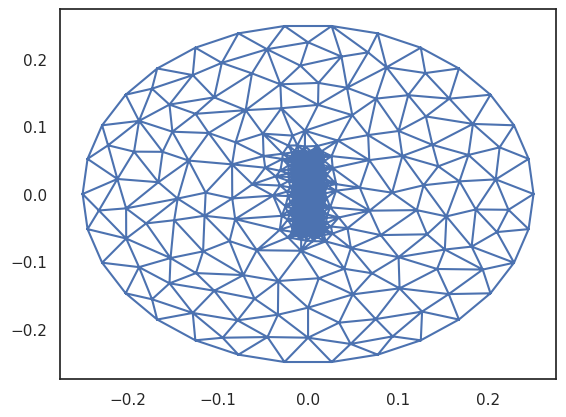

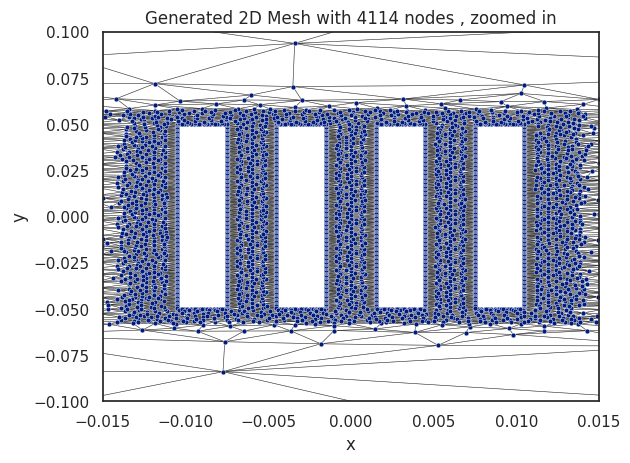

In [28]:
nodes, elements, boundary_edge, boundary_inidces, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("LoesungWS1819/KlausurWS1819_Netz.npz", show=True)

fig, ax = plt.subplots()
ax.set_xlim(-5*DX, 5*DX)
ax.set_ylim(-HH, HH)
myfunc.plot_knots_elements(nodes, elements, ax=ax, title_suffix=", zoomed in")

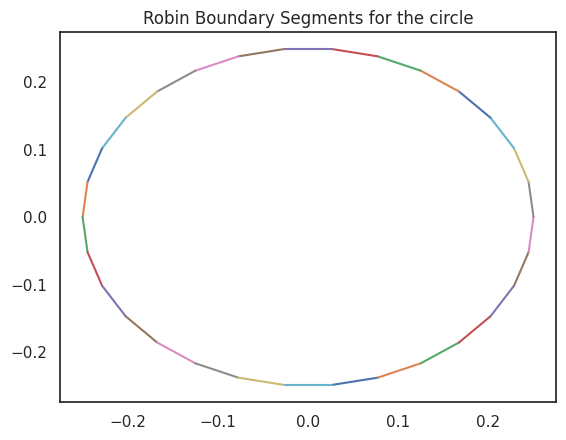

In [29]:
#______________
# Dirichlet Boundary
def dirichlet_func(x, y):
    OFFSET = 1e-4

    mask1 = (   # check if inside layer 1
        (x >= -3.5*DX -OFFSET) & (x <= -2.5*DX +OFFSET) &
        (y >= -0.5*HH -OFFSET) & (y <= 0.5*HH +OFFSET)
    )
    mask3 = (   # check if inside layer 3
        (x >= 0.5*DX -OFFSET) & (x <= 1.5*DX +OFFSET) & 
        (y >= -0.5*HH -OFFSET) & (y <= 0.5*HH +OFFSET)
    )
    mask = mask1 | mask3

    return np.where(mask, V0, -V0)    

# !: Dirichlet indices are not working !
# DIRICHLICHT_POINTS = [[-0.5*DX, -0.5*HH], [-1.5*DX, 0.5*HH]]
# DIRICHLET_INDICES = np.array(mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces, DIRICHLICHT_POINTS, ["Nodes", "Nodes"])).flatten()

# plt.scatter(nodes[DIRICHLET_INDICES][:,0], nodes[DIRICHLET_INDICES][:,1])
# plt.show()

#______________
# Robin Boundary
def robin_gamma(x, y):
    trig =  np.sqrt(x**2 + y**2)
    return sci.constants.epsilon_0 / ( trig * np.log(trig)) * -1

def robin_rhs(x, y):
    return 0

# robin indices should be all segments on the edge of the circle
BOUNDARY_POINTS = [[0,-RA],[0, RA],[0, -RA]]
ROBIN_INDICES = mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces,BOUNDARY_POINTS, ["Segments", "Segments"])
ROBIN_INDICES = np.concatenate([ROBIN_INDICES[0], ROBIN_INDICES[1]])

fig, ax = plt.subplots()
for segment in nodes[ROBIN_INDICES]:
    x_val = [segment[0,0], segment[1,0]]
    y_val = [segment[0,1], segment[1,1]]

    ax.plot(x_val, y_val)

plt.title("Robin Boundary Segments for the circle")
plt.show()

In [30]:
NL =4

RU=[]
RO=[]
HolPoi=[]
x0=-NL*DX+DX/2.
for k in range(NL):
  x=x0+k*2*DX
  RU+=[[x,-HH/2.]]
  RO+=[[x+DX,HH/2.]]

# Randkurven
Ps=[[RA,0],[RA,0]]
typ=['Segments']+NL*['Nodes']
for k in range(NL):
  Ps+=[RU[k],RU[k]]

bseg=mt.RetrieveSegments(nodes,boundary_edge,boundary_inidces,Ps,typ)

# Robin-Rand 
R0=bseg[0]
# ROBIN_INDICES = np.array(R0)

#Dirichlet-Rand
G0=[]
for k in range(1,NL+1):
  G0+=bseg[k] 

DIRICHLET_INDICES = np.array(G0).flatten()

## Solve 2D FEM

In [31]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(nodes, elements, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(nodes, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(nodes, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet_func)

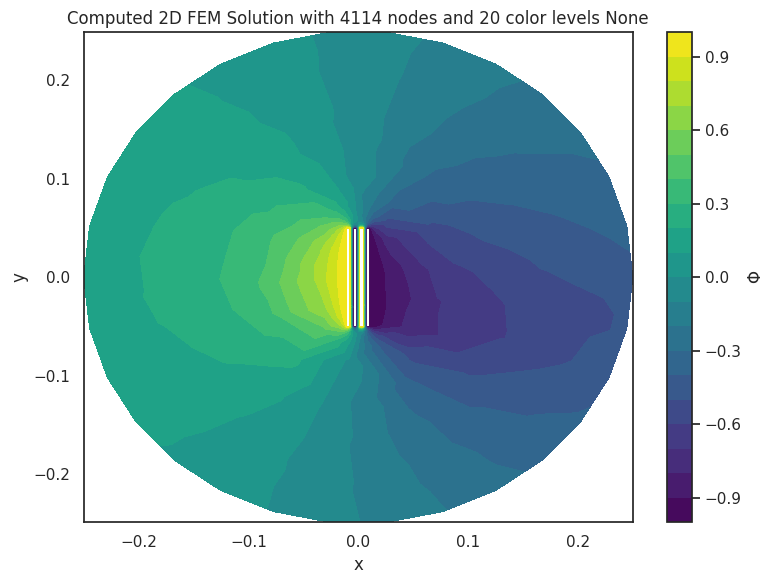

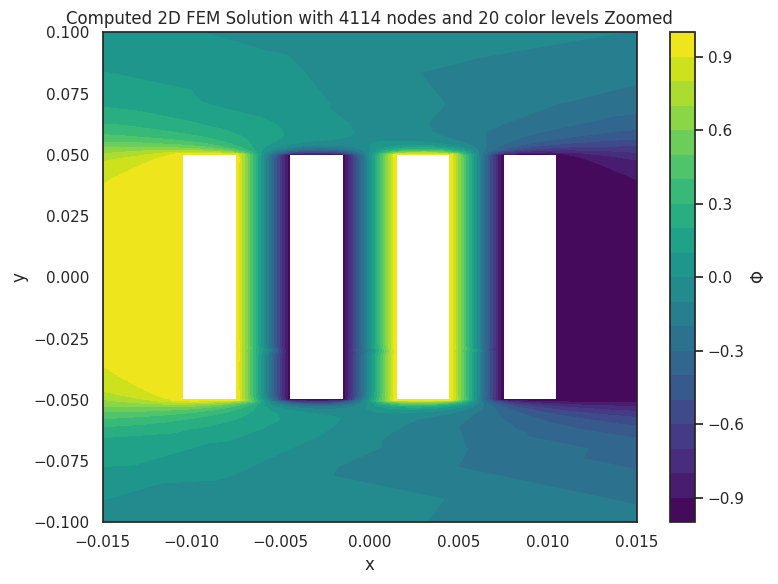

             x         y       Phi
0     0.250000  0.000000 -0.432399
1     0.244537  0.051978 -0.368786
2     0.228386  0.101684 -0.318505
3     0.202254  0.146946 -0.270160
4     0.167283  0.185786 -0.221797
...        ...       ...       ...
4109 -0.114780 -0.032239  0.299076
4110 -0.080369  0.076478  0.271054
4111 -0.030716  0.162337  0.017207
4112 -0.033442 -0.178642 -0.045005
4113 -0.144605 -0.006753  0.261734

[4114 rows x 3 columns]


In [32]:
solution = myfunc.solve_system(nodes, stiffness_matrix, load_vector)
myfunc.plot_result(elements, solution, levels=20)

fig, axis = plt.subplots(figsize=(8, 6))
axis.set_xlim(-5*DX, 5*DX)
axis.set_ylim(-HH, HH)
myfunc.plot_result(elements, solution, levels=20, ax=axis, suffix="Zoomed")
print(solution)